# Active-Set PCA Forecasting

This notebook evaluates an active-window-aware PCA/logistic forecasting benchmark for Universe B. The key change from the rectangular panel benchmark is that supervised rows exist only for markets active at timestamp `t`; structurally inactive cells are not treated as missing observations.

Persistent homology is intentionally not implemented here.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "src" / "active_set_forecasting.py").exists():
            return candidate
        nested = candidate / "polymarket_topology"
        if (nested / "src" / "active_set_forecasting.py").exists():
            return nested
    raise FileNotFoundError("Could not locate polymarket_topology project root")

ROOT = find_project_root(Path.cwd().resolve())
sys.path.append(str(ROOT / "src"))

from active_set_forecasting import run_all

PROCESSED = ROOT / "data" / "processed"
FIGURES = ROOT / "notebooks" / "figures" / "active_set_pca"
FIGURES.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)
plt.style.use("default")

/Users/aaditjerfy/Documents/Playground/Topology-of-Prediction-Market-Belief-Dynamics/polymarket_topology/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


## Reproducibility Switch

The full benchmark has already been run by `src/active_set_forecasting.py`. Set `RUN_BACKTEST = True` to regenerate all output artifacts from inside the notebook.

In [2]:
RUN_BACKTEST = False

if RUN_BACKTEST:
    supervised_df, predictions_df, results_df, calibration_df, summary_text = run_all(
        PROCESSED / "candidate_universe_markets.parquet",
        PROCESSED / "prices_long.parquet",
        PROCESSED / "universe_b_macro_crypto_panel.parquet",
        PROCESSED,
    )
else:
    supervised_df = pd.read_parquet(PROCESSED / "active_set_supervised_dataset.parquet")
    predictions_df = pd.read_parquet(PROCESSED / "active_set_pca_predictions.parquet")
    results_df = pd.read_csv(PROCESSED / "active_set_pca_forecast_results.csv", parse_dates=["train_start", "train_end", "test_start", "test_end"])
    calibration_df = pd.read_csv(PROCESSED / "active_set_pca_calibration_by_decile.csv")
    summary_text = (PROCESSED / "active_set_pca_summary.md").read_text(encoding="utf-8")

print("supervised", supervised_df.shape)
print("predictions", predictions_df.shape)
print("results", results_df.shape)
print("calibration", calibration_df.shape)

supervised (532979, 9)
predictions (7074400, 73)
results (2850, 17)
calibration (4161, 8)


## Part 1: Active-Set Supervised Dataset

In [3]:
dataset_summary = pd.DataFrame([{
    "markets": supervised_df["market_id"].nunique(),
    "rows": len(supervised_df),
    "unique_market_yes_rate": supervised_df.drop_duplicates("market_id")["Y_i"].mean(),
    "row_yes_rate": supervised_df["Y_i"].mean(),
    "timestamp_min": supervised_df["timestamp"].min(),
    "timestamp_max": supervised_df["timestamp"].max(),
    "active_count_min": supervised_df.groupby("timestamp")["market_id"].nunique().min(),
    "active_count_median": supervised_df.groupby("timestamp")["market_id"].nunique().median(),
    "active_count_mean": supervised_df.groupby("timestamp")["market_id"].nunique().mean(),
    "active_count_max": supervised_df.groupby("timestamp")["market_id"].nunique().max(),
}])
display(dataset_summary)
display(supervised_df.head())

,markets,rows,unique_market_yes_rate,row_yes_rate,timestamp_min,timestamp_max,active_count_min,active_count_median,active_count_mean,active_count_max
0,171,532979,0.111111,0.100728,2024-08-06 17:00:00+00:00,2026-04-01 08:00:00+00:00,17,34.0,36.848659,68


,timestamp,market_id,p_i_t,active_market_count_t,Y_i,broad_domain,broad_family,volume,resolved_outcome
0,2024-08-06 17:00:00+00:00,254576,0.0850,23,0,macro,macro_fed_rates,3.982526e+06,No
1,2024-08-06 17:00:00+00:00,254577,0.2150,23,0,macro,macro_fed_rates,8.337157e+06,No
2,2024-08-06 17:00:00+00:00,254578,0.2605,23,1,macro,macro_fed_rates,6.812525e+06,Yes
3,2024-08-06 17:00:00+00:00,254579,0.2280,23,0,macro,macro_fed_rates,6.683118e+06,No
4,2024-08-06 17:00:00+00:00,254580,0.1195,23,0,macro,macro_fed_rates,2.016909e+07,No


,broad_domain,broad_family,markets,yes_rate,avg_volume
0,crypto,crypto_btc,56,0.017857,8.469909e+06
1,crypto,crypto_eth,14,0.000000,7.832503e+06
2,crypto,crypto_microstrategy,2,0.500000,1.319741e+07
3,crypto,crypto_policy,2,0.000000,1.442556e+07
4,crypto,crypto_regulation,1,0.000000,7.603059e+06
5,macro,macro_fed_rates,96,0.177083,4.008021e+07


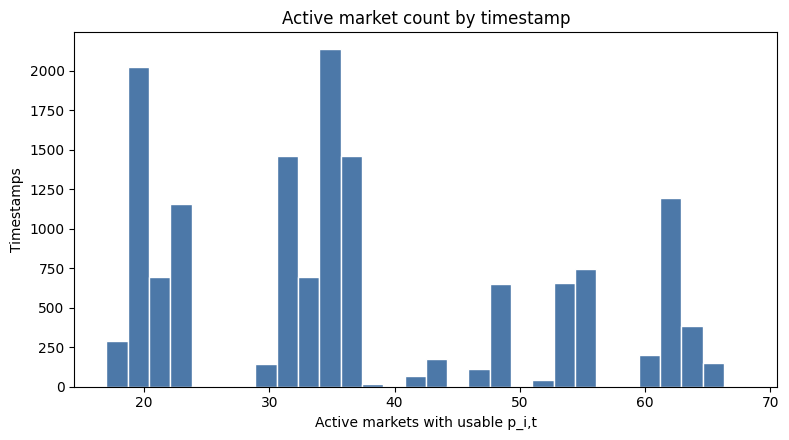

In [4]:
family_balance = supervised_df.drop_duplicates("market_id").groupby(["broad_domain", "broad_family"]).agg(
    markets=("market_id", "nunique"),
    yes_rate=("Y_i", "mean"),
    avg_volume=("volume", "mean"),
).reset_index().sort_values(["broad_domain", "broad_family"])
display(family_balance)

active_counts = supervised_df.groupby("timestamp")["market_id"].nunique()
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(active_counts, bins=30, color="#4C78A8", edgecolor="white")
ax.set_title("Active market count by timestamp")
ax.set_xlabel("Active markets with usable p_i,t")
ax.set_ylabel("Timestamps")
plt.tight_layout()
plt.savefig(FIGURES / "01_active_market_count_distribution.png", dpi=160, bbox_inches="tight")
plt.show()

## Part 2: Active-Aware PCA Representations

Representation A, `active_filled_pca`, uses the Universe B market panel but masks structurally inactive cells. Active missing cells are imputed from training active observations; inactive cells become zero after training-set centering, so they mean no active deviation rather than missing probability.

Representation B, `family_pca`, aggregates active markets by `broad_family` at each timestamp using mean, median, standard deviation, and active count, then fits PCA on that fixed family-level state.

## Part 3 and 4: Chronological Forecasting Evaluation

In [5]:
overall = results_df[(results_df["eval_group_type"] == "overall") & (results_df["status"] == "ok")].copy()
model_summary = (
    overall.groupby(["representation", "model", "class_weight"], as_index=False)
    .agg(
        folds=("fold", "nunique"),
        n_obs=("n_obs", "sum"),
        n_components_median=("n_components", "median"),
        n_components_min=("n_components", "min"),
        n_components_max=("n_components", "max"),
        brier=("brier", "mean"),
        log_loss=("log_loss", "mean"),
        avg_pred=("avg_pred", "mean"),
        avg_actual=("avg_actual", "mean"),
    )
    .sort_values(["brier", "log_loss"])
)
baseline = model_summary[model_summary["representation"] == "market_probability"].iloc[0]
model_summary["brier_delta_vs_baseline"] = model_summary["brier"] - baseline["brier"]
model_summary["log_loss_delta_vs_baseline"] = model_summary["log_loss"] - baseline["log_loss"]
display(model_summary.head(30))

,representation,model,class_weight,folds,n_obs,n_components_median,n_components_min,n_components_max,brier,log_loss,avg_pred,avg_actual,brier_delta_vs_baseline,log_loss_delta_vs_baseline
15,family_pca,fixed_2_standard,standard,17,282976,2.0,2,2,0.044509,0.162468,0.093003,0.08942,-0.004371,-0.004793
17,family_pca,fixed_5_standard,standard,17,282976,5.0,5,5,0.044529,0.162564,0.093862,0.08942,-0.004351,-0.004698
19,family_pca,var_85_standard,standard,17,282976,6.0,5,6,0.044663,0.163462,0.091233,0.08942,-0.004216,-0.003800
21,family_pca,var_90_standard,standard,17,282976,7.0,7,8,0.045241,0.166199,0.091861,0.08942,-0.003638,-0.001063
9,active_filled_pca,var_90_standard,standard,17,282976,33.0,23,39,0.046732,0.179960,0.085609,0.08942,-0.002147,0.012699
1,active_filled_pca,fixed_10_standard,standard,17,282976,10.0,10,10,0.046905,0.181615,0.074139,0.08942,-0.001975,0.014354
11,active_filled_pca,var_95_standard,standard,17,282976,49.0,33,58,0.047003,0.181320,0.090272,0.08942,-0.001877,0.014059
7,active_filled_pca,var_85_standard,standard,17,282976,24.0,17,28,0.047099,0.181185,0.082794,0.08942,-0.001780,0.013924
3,active_filled_pca,fixed_2_standard,standard,17,282976,2.0,2,2,0.048508,0.190876,0.064239,0.08942,-0.000372,0.023614
5,active_filled_pca,fixed_5_standard,standard,17,282976,5.0,5,5,0.048520,0.191460,0.061739,0.08942,-0.000359,0.024198


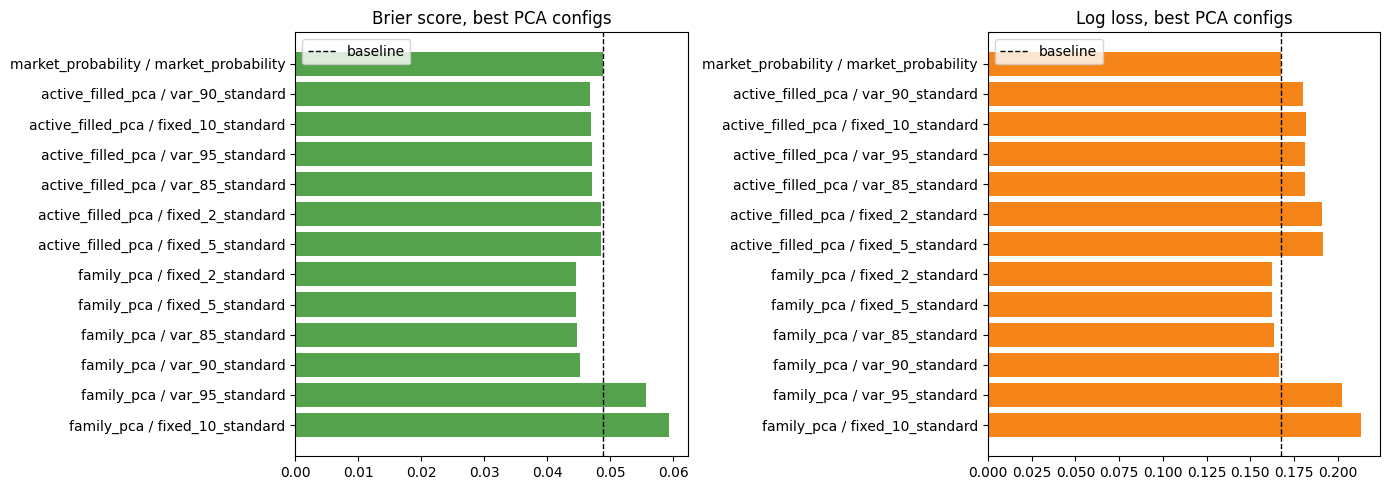

In [6]:
plot_summary = model_summary.copy()
plot_summary["label"] = plot_summary["representation"] + " / " + plot_summary["model"]
plot_summary = pd.concat([
    plot_summary[plot_summary["representation"] == "market_probability"],
    plot_summary[plot_summary["representation"] == "active_filled_pca"].sort_values("brier").head(6),
    plot_summary[plot_summary["representation"] == "family_pca"].sort_values("brier").head(6),
])
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].barh(plot_summary["label"], plot_summary["brier"], color="#54A24B")
axes[0].axvline(baseline["brier"], color="black", linestyle="--", linewidth=1, label="baseline")
axes[0].set_title("Brier score, best PCA configs")
axes[0].invert_yaxis()
axes[0].legend()
axes[1].barh(plot_summary["label"], plot_summary["log_loss"], color="#F58518")
axes[1].axvline(baseline["log_loss"], color="black", linestyle="--", linewidth=1, label="baseline")
axes[1].set_title("Log loss, best PCA configs")
axes[1].invert_yaxis()
axes[1].legend()
plt.tight_layout()
plt.savefig(FIGURES / "02_model_metric_comparison.png", dpi=160, bbox_inches="tight")
plt.show()

,fold,representation,model,brier_improvement,log_loss_improvement
9,1,active_filled_pca,var_90_standard,-0.005487,-0.148239
13,1,family_pca,fixed_2_standard,0.009948,0.032830
34,2,active_filled_pca,var_90_standard,0.008263,0.014843
38,2,family_pca,fixed_2_standard,0.010735,0.028822
59,3,active_filled_pca,var_90_standard,0.008612,0.025622
63,3,family_pca,fixed_2_standard,0.008452,0.026217
84,4,active_filled_pca,var_90_standard,0.000164,-0.001530
88,4,family_pca,fixed_2_standard,0.007754,0.025983
109,5,active_filled_pca,var_90_standard,0.013022,0.037179
113,5,family_pca,fixed_2_standard,0.013639,0.038880


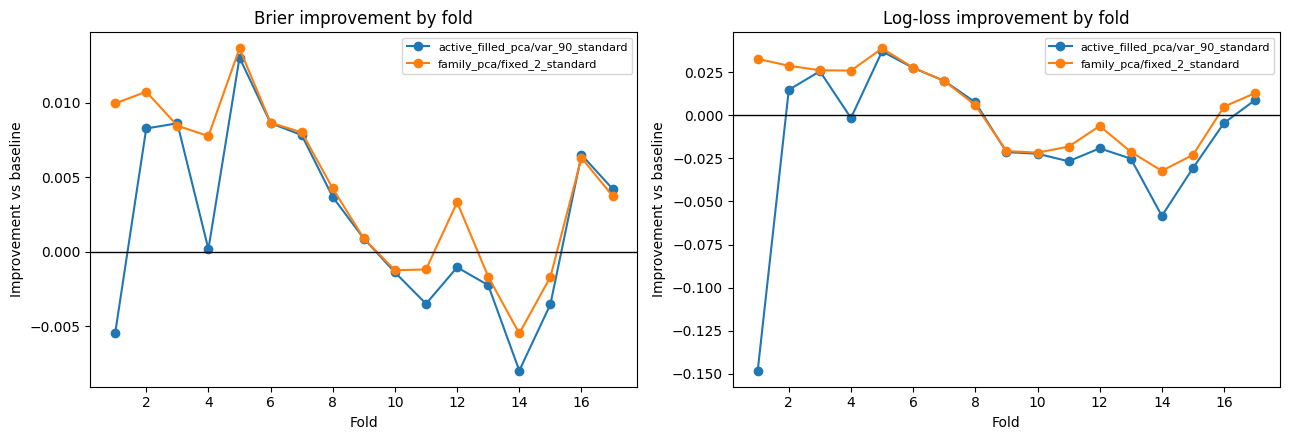

In [7]:
fold_perf = overall.merge(
    overall[overall["representation"] == "market_probability"][["fold", "brier", "log_loss"]].rename(columns={"brier": "baseline_brier", "log_loss": "baseline_log_loss"}),
    on="fold",
    how="left",
)
fold_perf["brier_improvement"] = fold_perf["baseline_brier"] - fold_perf["brier"]
fold_perf["log_loss_improvement"] = fold_perf["baseline_log_loss"] - fold_perf["log_loss"]
best_active_model = model_summary[model_summary["representation"] == "active_filled_pca"].sort_values("brier").iloc[0]["model"]
best_family_model = model_summary[model_summary["representation"] == "family_pca"].sort_values("brier").iloc[0]["model"]
fold_plot = fold_perf[
    ((fold_perf["representation"] == "active_filled_pca") & (fold_perf["model"] == best_active_model)) |
    ((fold_perf["representation"] == "family_pca") & (fold_perf["model"] == best_family_model))
]
display(fold_plot[["fold", "representation", "model", "brier_improvement", "log_loss_improvement"]].head(40))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for (rep, model), g in fold_plot.groupby(["representation", "model"]):
    axes[0].plot(g["fold"], g["brier_improvement"], marker="o", label=f"{rep}/{model}")
    axes[1].plot(g["fold"], g["log_loss_improvement"], marker="o", label=f"{rep}/{model}")
for ax in axes:
    ax.axhline(0, color="black", linewidth=1)
    ax.set_xlabel("Fold")
    ax.set_ylabel("Improvement vs baseline")
    ax.legend(fontsize=8)
axes[0].set_title("Brier improvement by fold")
axes[1].set_title("Log-loss improvement by fold")
plt.tight_layout()
plt.savefig(FIGURES / "03_fold_improvements.png", dpi=160, bbox_inches="tight")
plt.show()

## Calibration By Decile

,label,prob_decile,n_obs,avg_pred,avg_actual
0,active_filled_pca / var_90_standard,0,244309,0.022698,0.029117
1,active_filled_pca / var_90_standard,1,11773,0.145937,0.115282
2,active_filled_pca / var_90_standard,2,5152,0.242041,0.181678
3,active_filled_pca / var_90_standard,3,3446,0.347132,0.328654
4,active_filled_pca / var_90_standard,4,3320,0.449137,0.505535
5,active_filled_pca / var_90_standard,5,2068,0.543752,0.521992
6,active_filled_pca / var_90_standard,6,2542,0.653274,0.736325
7,active_filled_pca / var_90_standard,7,2417,0.747171,0.636458
8,active_filled_pca / var_90_standard,8,2608,0.846375,0.723073
9,active_filled_pca / var_90_standard,9,5341,0.947998,0.832730


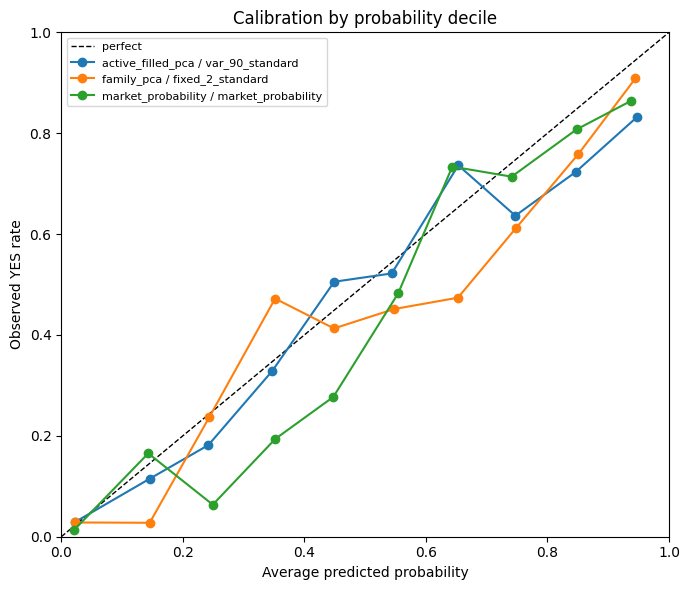

In [8]:
best_models = [
    ("market_probability", "market_probability", "none"),
    ("active_filled_pca", best_active_model, "standard" if best_active_model.endswith("standard") else "balanced"),
    ("family_pca", best_family_model, "standard" if best_family_model.endswith("standard") else "balanced"),
]
cal_parts = []
for rep, model, cw in best_models:
    part = calibration_df[(calibration_df["representation"] == rep) & (calibration_df["model"] == model) & (calibration_df["class_weight"] == cw)].copy()
    part["label"] = rep + " / " + model
    cal_parts.append(part)
cal_plot = pd.concat(cal_parts, ignore_index=True)
cal_summary = cal_plot.groupby(["label", "prob_decile"], as_index=False).agg(n_obs=("n_obs", "sum"), avg_pred=("avg_pred", "mean"), avg_actual=("avg_actual", "mean"))
display(cal_summary.head(40))

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot([0, 1], [0, 1], color="black", linestyle="--", linewidth=1, label="perfect")
for label, g in cal_summary.groupby("label"):
    ax.plot(g["avg_pred"], g["avg_actual"], marker="o", label=label)
ax.set_title("Calibration by probability decile")
ax.set_xlabel("Average predicted probability")
ax.set_ylabel("Observed YES rate")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(FIGURES / "04_calibration_by_decile.png", dpi=160, bbox_inches="tight")
plt.show()

## Performance By Family And Active-Market Count

In [9]:
family_results = results_df[(results_df["eval_group_type"] == "broad_family") & (results_df["status"] == "ok")].copy()
family_focus = family_results[
    ((family_results["representation"] == "market_probability") & (family_results["model"] == "market_probability")) |
    ((family_results["representation"] == "active_filled_pca") & (family_results["model"] == best_active_model)) |
    ((family_results["representation"] == "family_pca") & (family_results["model"] == best_family_model))
]
family_table = family_focus.groupby(["representation", "model", "eval_group"], as_index=False).agg(n_obs=("n_obs", "sum"), brier=("brier", "mean"), log_loss=("log_loss", "mean"), avg_actual=("avg_actual", "mean"))
display(family_table.sort_values(["eval_group", "representation"]))

bucket_results = results_df[(results_df["eval_group_type"] == "active_market_count_bucket") & (results_df["status"] == "ok")].copy()
bucket_focus = bucket_results[
    ((bucket_results["representation"] == "market_probability") & (bucket_results["model"] == "market_probability")) |
    ((bucket_results["representation"] == "active_filled_pca") & (bucket_results["model"] == best_active_model)) |
    ((bucket_results["representation"] == "family_pca") & (bucket_results["model"] == best_family_model))
]
bucket_table = bucket_focus.groupby(["representation", "model", "eval_group"], as_index=False).agg(n_obs=("n_obs", "sum"), brier=("brier", "mean"), log_loss=("log_loss", "mean"), avg_actual=("avg_actual", "mean"))
display(bucket_table.sort_values(["eval_group", "representation"]))

,representation,model,eval_group,n_obs,brier,log_loss,avg_actual
0,active_filled_pca,var_90_standard,crypto_btc,58094,0.015268,0.067894,0.000000
5,family_pca,fixed_2_standard,crypto_btc,58094,0.019691,0.082607,0.000000
10,market_probability,market_probability,crypto_btc,58094,0.035290,0.133633,0.000000
1,active_filled_pca,var_90_standard,crypto_eth,28601,0.020593,0.074699,0.000000
6,family_pca,fixed_2_standard,crypto_eth,28601,0.026992,0.094530,0.000000
11,market_probability,market_probability,crypto_eth,28601,0.040412,0.134711,0.000000
2,active_filled_pca,var_90_standard,crypto_microstrategy,6822,0.401374,1.430041,0.448606
7,family_pca,fixed_2_standard,crypto_microstrategy,6822,0.407258,1.392773,0.448606
12,market_probability,market_probability,crypto_microstrategy,6822,0.370256,1.153116,0.448606
3,active_filled_pca,var_90_standard,crypto_policy,3627,0.000830,0.020531,0.000000


,representation,model,eval_group,n_obs,brier,log_loss,avg_actual
0,active_filled_pca,var_90_standard,26-50,75423,0.049926,0.189818,0.115165
2,family_pca,fixed_2_standard,26-50,75423,0.047578,0.174344,0.115165
4,market_probability,market_probability,26-50,75423,0.050618,0.177012,0.115165
1,active_filled_pca,var_90_standard,51-100,207553,0.045234,0.175047,0.072562
3,family_pca,fixed_2_standard,51-100,207553,0.042556,0.152544,0.072562
5,market_probability,market_probability,51-100,207553,0.048742,0.164872,0.072562


## Class Weighting

In [10]:
weight_compare = model_summary[model_summary["representation"].isin(["active_filled_pca", "family_pca"])].copy()
weight_compare["base_model"] = weight_compare["model"].str.replace("_standard", "", regex=False).str.replace("_balanced", "", regex=False)
weight_pivot = weight_compare.pivot_table(index=["representation", "base_model"], columns="class_weight", values=["brier", "log_loss", "n_components_median"])
display(weight_pivot.head(40))

brier            log_loss           n_components_median         
class_weight                  balanced  standard  balanced  standard            balanced standard
representation    base_model                                                                     
active_filled_pca fixed_10    0.074444  0.046905  0.275979  0.181615                10.0     10.0
                  fixed_2     0.068282  0.048508  0.250074  0.190876                 2.0      2.0
                  fixed_5     0.065834  0.048520  0.240118  0.191460                 5.0      5.0
                  var_85      0.076932  0.047099  0.285345  0.181185                24.0     24.0
                  var_90      0.082405  0.046732  0.302357  0.179960                33.0     33.0
                  var_95      0.089312  0.047003  0.323671  0.181320                49.0     49.0
family_pca        fixed_10    0.095414  0.059266  0.347565  0.213407                10.0     10.0
                  fixed_2     0.094063  0.044509  0.340409  0.162468                 2.0      2.0
                  fixed_5     0.092407  0.044529  0.334113  0.162564                 5.0      5.0
                  var_85      0.089237  0.044663  0.322715  0.163462                 6.0      6.0
                  var_90      0.084801  0.045241  0.308641  0.166199                 7.0      7.0
                  var_95      0.089622  0.055587  0.327848  0.202357                 9.0      9.0

## Final Summary

In [11]:
print(summary_text)

ACTIVE-SET PCA FORECASTING SUMMARY

1. Dataset:
- number of markets: 171
- number of supervised rows: 532,979
- YES rate by unique market: 0.111
- active market count distribution: min 17, median 34.0, mean 36.8, max 68

2. Baseline:
- Brier: 0.0489
- log loss: 0.1673

3. Best active-filled PCA:
- model: var_90_standard
- components: median 33, range 23-39
- Brier: 0.0467
- log loss: 0.1800
- improves over baseline: Brier yes, log loss no

4. Best family-level PCA:
- model: fixed_2_standard
- components: median 2, range 2-2
- Brier: 0.0445
- log loss: 0.1625
- improves over baseline: Brier yes, log loss yes

5. Calibration:
- best log-loss model: family_pca / fixed_2_standard with log loss 0.1625
- class weighting helps on mean Brier across PCA configs: no
- Calibration should be judged against the decile output file; log loss remains the stricter warning signal for overconfident rare-positive errors.

6. Interpretation:
- Active-set PCA removes the structural-missingness artifact by b